In [1]:
from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from algorithms.EKI import EnsembleKalmanInversion

from time import perf_counter

jax.config.update('jax_platform_name', 'cpu')

print(jax.devices())



An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[CpuDevice(id=0)]


In [2]:
beta_true = jnp.log(0.3)
gamma_true = jnp.log(0.1)

t_vec = jnp.linspace(0,100,100)

def rhs(t,state,args):
    S,I,R = state
    N = S + I + R

    beta,gamma = args

    beta = jnp.exp(beta)
    gamma = jnp.exp(gamma)

    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I

    return jnp.array([dS,dI,dR])

In [3]:
"""The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector."""


def model(ts, y0, par):
    solution = diffrax.diffeqsolve(
        ODETerm(rhs),
        diffrax.Tsit5(),
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        args=par,
        saveat=diffrax.SaveAt(ts=ts),  # At which points to save the output
        stepsize_controller=diffrax.PIDController(1e-3, 1e-3),
    )
    return solution.ys


def map(par, _):
    beta_prop, gamma_prop = par
    full_state = jnp.maximum(
        model(t_vec, jnp.array([100.0, 1.0, 0.0]), (beta_prop, gamma_prop)), 1e-6
    )

    return full_state[:, 1]


In [4]:
# Initializing the random number generator
rng_key = jax.random.PRNGKey(0)

# Split the key to avoid reusing the same key.
# JAX requires explicit key management.
noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''
full_state = jnp.maximum(model(t_vec,jnp.array([100.,1.0,0.0]),(beta_true,gamma_true)),1e-6)

observations = jax.random.poisson(noise_key,full_state[:,1])


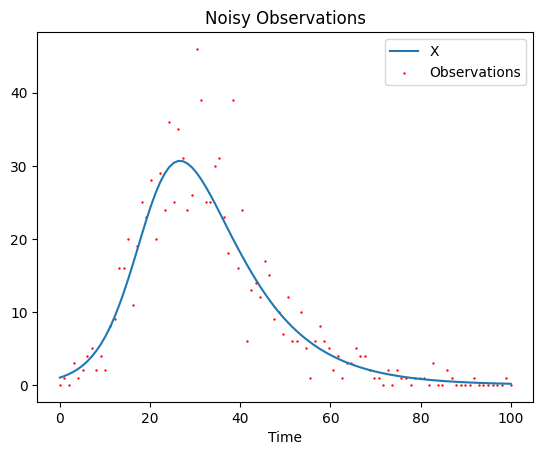

In [5]:
plt.title('Noisy Observations')
plt.plot(t_vec,full_state[:,1],label = 'X')
plt.scatter(t_vec,observations,s = 0.5,color = 'red', label = 'Observations')
plt.xlabel('Time')
plt.legend()
plt.show()

In [6]:
rng_key, noise_key = jax.random.split(rng_key)

dim_output = 2
gamma = 100 * jnp.eye(len(observations))

num_ensemble_members = 10

rng_key, init_ensemble_key, init_key = jax.random.split(rng_key, 3)

initial_ensemble = jnp.log(jnp.array([0.5,0.5])) + jax.random.normal(
    init_ensemble_key, (num_ensemble_members, dim_output)
)

(final_ensemble,_), _ = EnsembleKalmanInversion(
    initial_ensemble,
    observations,
    gamma,
    lambda x, y: jax.vmap(map, in_axes=(0, 0))(x, y),
    0.01,
    init_key,
)

print(jnp.mean(jnp.exp(final_ensemble),axis = 0))

[0.29627487 0.09750574]
